# Full-Day Drift Walkthrough

This is a walkthrough of the analysis for one full day of MLB games, with the goal of understanding the market dynamics within each game and how to measure drift. This is a critical step before we scale to many games and many days, so we want to be very clear on the data shape, the analytical primitives, and the end-to-end process for one example. The date we are using is **May 20, 2026**. 
The goal here is is to:

1. Explore the data shape and analytical primitives for one market in depth, so we can be confident in our approach when we scale to many markets.
2. Demonstrate the data shape end-to-end (market metadata, orderbook snapshot, trade history) for one real example.
3. Establish the analytical primitives (price metrics, time alignment, drift definition) we'll reuse when we scale to many markets.
4. Cache the data to parquet so this notebook renders cleanly on GitHub even when the Snowflake warehouse is paused.

### Prerequisites

This notebook reads from the **dbt staging/marts** (`fct_markets`, `fct_market_orderbooks`, `stg_kalshi_market_trades`), not from `RAW`. If you've just scraped fresh data for this market, run `dbt run` first so the marts pick up the new rows:

```bash
dbt run --project-dir dbt --profiles-dir dbt
```

The first cell run will hit Snowflake once and write parquet to `analysis/data/single_market_KXMLBSPREAD-26MAY101920DETKC-DET2/`. Subsequent re-runs load from that cache and don't need a warm warehouse.

### Caveat
Due to an outage on May 20, 2026 (captured in https://github.com/GGarrido28/snowflake-market-data-platform/issues/81) the data set is incomplete. We have orderbook data through approximately 6:45 CST. This means we won't be able to see the full pre-game to in-game transition for all markets, but we can still use the available data to understand the process and primitives. We will need to be mindful of this limitation as we interpret the results.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv

from market_data_platform.warehouse import SnowflakeManager
from market_data_platform.utils.timezone import utc_to_eastern

# Walk up from the notebook's cwd to find the repo root .env
load_dotenv(find_dotenv())

MARKET_DATE = "2026-05-20"
DATA_DIR = Path("data") / f"full_day_{MARKET_DATE}"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def cached_query(query: str, name: str, snowflake: SnowflakeManager | None = None) -> pd.DataFrame:
    """Load a Snowflake query result from parquet cache if present, else query and cache.

    Keeps every notebook re-executable without warehouse access as long as the cache
    is on disk — the rendered cell output in the .ipynb is what ships to GitHub.
    """
    cache_path = DATA_DIR / f"{name}.parquet"
    if cache_path.exists():
        print(f"  loaded {name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)
    if snowflake is None:
        raise RuntimeError(
            f"Cache miss for {name} and no Snowflake connection provided. "
            "Pass a SnowflakeManager to populate the cache."
        )
    print(f"  cache miss for {name}; querying Snowflake...")
    rows = snowflake.execute(query)
    df = pd.DataFrame(rows)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {len(df)} rows to {cache_path}")
    return df

In [2]:
EVENT_CACHE_FILES = ("markets", "orderbooks", "trades")


def sql_literal(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def event_cache_dir(event_ticker: str) -> Path:
    return DATA_DIR / event_ticker


def event_cache_path(event_ticker: str, name: str) -> Path:
    return event_cache_dir(event_ticker) / f"{name}.parquet"


def missing_event_cache_files(event_ticker: str) -> list[str]:
    return [
        name
        for name in EVENT_CACHE_FILES
        if not event_cache_path(event_ticker, name).exists()
    ]


def write_event_cache(event_ticker: str, name: str, df: pd.DataFrame) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {event_ticker}/{name}: {len(df)} rows -> {cache_path}")
    return df


def cached_event_query(
    event_ticker: str,
    name: str,
    query: str,
    snowflake: SnowflakeManager,
) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    if cache_path.exists():
        print(f"  loaded {event_ticker}/{name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)

    print(f"  cache miss for {event_ticker}/{name}; querying Snowflake...")
    df = pd.DataFrame(snowflake.execute(query))
    return write_event_cache(event_ticker, name, df)


# Connect only when a missing cache requires Snowflake. Per dbt/macros/
# generate_schema_name.sql, staging models materialize in PROD.STAGE and mart
# models materialize in PROD.KALSHI.
snowflake = None
events_cache_path = DATA_DIR / "events.parquet"

try:
    if events_cache_path.exists():
        events_df = pd.read_parquet(events_cache_path)
        print(f"loaded events from cache ({events_cache_path})")
    else:
        snowflake = SnowflakeManager("PROD", "STAGE")
        events_query = f"""
        with mlb_events as (
            select
                event_ticker,
                try_to_date(
                    upper(substr(split_part(event_ticker, '-', 2), 1, 7)),
                    'YYMONDD'
                ) as game_date
            from PROD.STAGE.stg_kalshi_events
            where series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
        )
        select event_ticker
        from mlb_events
        where game_date = '{MARKET_DATE}'
        order by event_ticker
        """
        events_df = pd.DataFrame(snowflake.execute(events_query))
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        events_df.to_parquet(events_cache_path)
        print(f"wrote {len(events_df)} events to {events_cache_path}")

    events = events_df["event_ticker"].dropna().drop_duplicates().tolist()
    print(f"Found {len(events)} events on {MARKET_DATE}.")

    missing_events = {
        event: missing_event_cache_files(event)
        for event in events
        if missing_event_cache_files(event)
    }

    if not missing_events:
        print(
            "All per-event cache files are present. "
            "Delete an event directory or parquet file to refresh it."
        )
    else:
        if snowflake is None:
            snowflake = SnowflakeManager("PROD", "STAGE")

        print(f"Populating cache for {len(missing_events)} event(s).")
        for event, missing_names in missing_events.items():
            print(f"\n{event}: missing {', '.join(missing_names)}")
            event_sql = sql_literal(event)

            market_df = cached_event_query(
                event,
                "markets",
                f"""
                select *
                from PROD.KALSHI.fct_markets
                where event_ticker = {event_sql}
                  and series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
                order by market_ticker
                """,
                snowflake,
            )

            market_tickers = market_df["market_ticker"].dropna().drop_duplicates().tolist()
            print(f"  found {len(market_tickers)} markets")

            if not market_tickers:
                write_event_cache(event, "orderbooks", pd.DataFrame())
                write_event_cache(event, "trades", pd.DataFrame())
                continue

            ticker_sql = ", ".join(sql_literal(ticker) for ticker in market_tickers)

            orderbook_df = cached_event_query(
                event,
                "orderbooks",
                f"""
                select *
                from PROD.KALSHI.fct_market_orderbooks
                where market_ticker in ({ticker_sql})
                order by market_ticker
                """,
                snowflake,
            )

            trades_df = cached_event_query(
                event,
                "trades",
                f"""
                select *
                from PROD.STAGE.stg_kalshi_market_trades
                where market_ticker in ({ticker_sql})
                order by market_ticker, trade_time
                """,
                snowflake,
            )

            print(
                f"  cached {len(market_df)} markets, "
                f"{len(orderbook_df)} orderbooks, {len(trades_df)} trades"
            )
finally:
    if snowflake is not None:
        snowflake.close()

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 4.3.0, Python Version: 3.13.12, Platform: Windows-11-10.0.26200-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain


wrote 45 events to data\full_day_2026-05-20\events.parquet
Found 45 events on 2026-05-20.
Populating cache for 45 event(s).

KXMLBGAME-26MAY201305CINPHI: missing markets, orderbooks, trades
  cache miss for KXMLBGAME-26MAY201305CINPHI/markets; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/markets: 2 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\markets.parquet
  found 2 markets
  cache miss for KXMLBGAME-26MAY201305CINPHI/orderbooks; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/orderbooks: 2 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\orderbooks.parquet
  cache miss for KXMLBGAME-26MAY201305CINPHI/trades; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/trades: 18184 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\trades.parquet
  cached 2 markets, 2 orderbooks, 18184 trades

KXMLBGAME-26MAY201310BALTB: missing markets, orderbooks, trades
  cache miss for KXMLBGAME-26MAY201310BALTB/markets; querying Snowflak

# Available Events on May 20, 2026

In [9]:
display_events = pd.DataFrame(events, columns=["market_ticker"])
display_events['series_ticker'] = display_events['market_ticker'].str.split('-').str[0]
display_events['date_time_teams'] = display_events['market_ticker'].str.split('-').str[1]
display_events['date'] = display_events['date_time_teams'].str[:7] # first 7 chars is date e.g. 26MAY10
display_events['start_time'] = display_events['date_time_teams'].str[7:11] # next 4 chars is start time e.g. 13:05 EST
display_events['teams'] = display_events['date_time_teams'].str[11:] # remaining chars is teams e.g. DETKC
display_events['start_time_est'] = pd.to_datetime(display_events['start_time'], format='%H%M').dt.time
del display_events['date_time_teams'], display_events['start_time']
display_events

,market_ticker,series_ticker,date,teams,start_time_est
0,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME,26MAY20,CINPHI,13:05:00
1,KXMLBGAME-26MAY201310BALTB,KXMLBGAME,26MAY20,BALTB,13:10:00
2,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME,26MAY20,HOUMIN,13:40:00
3,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME,26MAY20,TEXCOL,15:10:00
4,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME,26MAY20,SFAZ,15:40:00
5,KXMLBGAME-26MAY201610CWSSEA,KXMLBGAME,26MAY20,CWSSEA,16:10:00
6,KXMLBGAME-26MAY201840ATLMIA,KXMLBGAME,26MAY20,ATLMIA,18:40:00
7,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME,26MAY20,CLEDET,18:40:00
8,KXMLBGAME-26MAY201845NYMWSH,KXMLBGAME,26MAY20,NYMWSH,18:45:00
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME,26MAY20,TORNYY,19:05:00


## Reminders

The `fct_markets` row tells us what the contract resolves on, when trading opened and closed, and the latest price snapshot at scrape time. A few Kalshi field-name conventions worth keeping in mind:

- **`_dollars`** suffix — the value is denominated in dollars (e.g. `last_price_dollars = 0.42` means the last trade cleared at 42¢).
- **`_fp`** suffix — Kalshi's "fixed-point" convention; the value is an integer count of contracts with no decimal scaling. `volume_fp` is the lifetime contract count traded.
- **`yes_*` / `no_*`** — two sides of the binary market. YES pays $1 if the market resolves true, NO pays $1 if it resolves false. Prices sum to ~$1 (modulo the bid-ask spread).

Market-level stats: 288 market tickers across 45 events on 2026-05-20.


,series_ticker,event_ticker,market_ticker,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,9311,0.43,0.99,0.661760,0.56,237.522003,0.01,50000.00,NaN,2026-05-20 14:00 EDT,2758
1,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,8695,0.57,0.01,0.364823,-0.56,196.706822,0.01,31666.00,NaN,2026-05-20 14:00 EDT,2580
2,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-BAL,7123,0.48,0.01,0.534707,-0.47,262.437728,0.01,78431.00,NaN,2026-05-20 15:00 EDT,2840
3,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-TB,16724,0.53,0.99,0.496240,0.46,296.561420,0.01,35898.26,NaN,2026-05-20 15:00 EDT,4960
4,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-HOU,4456,0.41,0.01,0.289719,-0.40,205.326313,0.02,27756.92,NaN,2026-05-20 14:00 EDT,1837
5,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-MIN,4726,0.60,0.99,0.703034,0.39,202.320491,0.02,50000.00,NaN,2026-05-20 15:00 EDT,1491
6,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-COL,11731,0.46,0.01,0.463273,-0.45,176.470827,0.02,20000.00,NaN,2026-05-20 17:00 EDT,5148
7,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-TEX,22041,0.54,0.99,0.520507,0.45,225.244596,0.01,35493.74,NaN,2026-05-20 17:00 EDT,9198
8,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-AZ,8176,0.55,0.99,0.647864,0.44,242.764329,0.01,27007.72,NaN,2026-05-20 16:00 EDT,2902
9,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-SF,6829,0.46,0.01,0.344172,-0.45,215.992492,0.01,32622.85,NaN,2026-05-20 16:00 EDT,2796



Series-level stats: 3 series rows. Price and orderbook columns are market-level means.


,series_ticker,market_count,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,30,166053,0.504000,0.504000,0.503722,1.110223e-17,220.971011,0.01,103285.38,0.371742,2026-05-20 17:00 EDT,29386
1,KXMLBSPREAD,94,27953,0.273298,0.247872,0.402346,-2.542553e-02,134.418515,0.01,50000.00,0.351566,2026-05-20 15:00 EDT,5053
2,KXMLBTOTAL,164,50062,0.582561,0.565549,0.493691,-1.701220e-02,165.851852,0.01,78902.36,0.289674,2026-05-20 18:00 EDT,9609


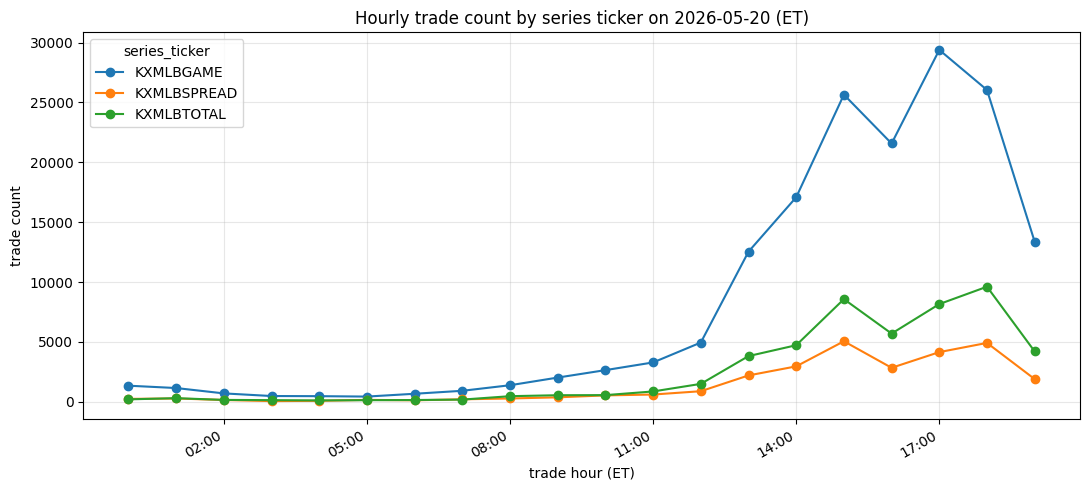

In [13]:
from IPython.display import display
from zoneinfo import ZoneInfo

import numpy as np

EASTERN = ZoneInfo('America/New_York')
analysis_date = pd.Timestamp(MARKET_DATE).date()
event_dirs = sorted(path for path in DATA_DIR.iterdir() if path.is_dir())

if not event_dirs:
    raise FileNotFoundError(f'No per-event cache directories found under {DATA_DIR}')

missing_cache_paths = [
    event_dir / f'{name}.parquet'
    for event_dir in event_dirs
    for name in EVENT_CACHE_FILES
    if not (event_dir / f'{name}.parquet').exists()
]
if missing_cache_paths:
    missing = ', '.join(str(path) for path in missing_cache_paths[:10])
    raise FileNotFoundError(f'Missing per-event cache files: {missing}')


def read_event_cache(name: str) -> pd.DataFrame:
    frames = []
    for event_dir in event_dirs:
        df = pd.read_parquet(event_dir / f'{name}.parquet').copy()
        df['cache_event_ticker'] = event_dir.name
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def coerce_numeric(df: pd.DataFrame, columns: tuple[str, ...]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def weighted_std(values: list[float], weights: list[float]) -> float:
    value_array = np.asarray(values, dtype='float64')
    weight_array = np.asarray(weights, dtype='float64')
    if len(value_array) == 0:
        return np.nan
    if len(value_array) == 1:
        return 0.0
    if not np.isfinite(weight_array).all() or weight_array.sum() <= 0:
        return float(np.nanstd(value_array))
    average = np.average(value_array, weights=weight_array)
    variance = np.average((value_array - average) ** 2, weights=weight_array)
    return float(np.sqrt(variance))


def orderbook_yes_implied_std(orderbook_value) -> float:
    if orderbook_value is None:
        return np.nan
    if isinstance(orderbook_value, str):
        orderbook = json.loads(orderbook_value)
    elif isinstance(orderbook_value, dict):
        orderbook = orderbook_value
    else:
        return np.nan

    prices = []
    sizes = []
    for side in ('yes_dollars', 'no_dollars'):
        for level in orderbook.get(side, []) or []:
            if not level:
                continue
            price = float(level[0])
            size = float(level[1]) if len(level) > 1 else 1.0
            prices.append(1.0 - price if side == 'no_dollars' else price)
            sizes.append(size)
    return weighted_std(prices, sizes)


all_markets_df = read_event_cache('markets')
all_orderbooks_df = read_event_cache('orderbooks')
all_trades_df = read_event_cache('trades')

all_markets_df = coerce_numeric(
    all_markets_df,
    ('last_price_dollars', 'volume_fp', 'liquidity_dollars'),
)
all_trades_df = coerce_numeric(
    all_trades_df,
    ('count_fp', 'yes_price_dollars', 'no_price_dollars'),
)

market_universe = all_markets_df.drop_duplicates('market_ticker').copy()
market_universe = market_universe[
    ['series_ticker', 'event_ticker', 'market_ticker', 'market_title', 'market_status']
]

all_trades_df['trade_time_et'] = utc_to_eastern(pd.to_datetime(all_trades_df['trade_time']))
day_trades_df = all_trades_df.loc[
    all_trades_df['trade_time_et'].dt.date == analysis_date
].copy()
day_trades_df['trade_hour_et'] = day_trades_df['trade_time_et'].dt.floor('h')

sorted_day_trades = day_trades_df.sort_values(['market_ticker', 'trade_time_et'])
trade_stats = sorted_day_trades.groupby('market_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    open_yes_price=('yes_price_dollars', 'first'),
    close_yes_price=('yes_price_dollars', 'last'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)

market_hourly = day_trades_df.groupby(
    ['market_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'peak_trade_hour_trade_count'})
market_peak = market_hourly.loc[
    market_hourly.groupby('market_ticker')['peak_trade_hour_trade_count'].idxmax()
].copy()
market_peak['peak_trade_hour_et'] = market_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
market_peak = market_peak[
    ['market_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

orderbook_stats = all_orderbooks_df.drop_duplicates('market_ticker').copy()
orderbook_stats['orderbook_yes_implied_std_dollars'] = orderbook_stats['orderbook'].apply(
    orderbook_yes_implied_std
)
orderbook_stats = orderbook_stats[
    ['market_ticker', 'orderbook_yes_implied_std_dollars']
]

market_stats = (
    market_universe
    .merge(trade_stats, on='market_ticker', how='left')
    .merge(orderbook_stats, on='market_ticker', how='left')
    .merge(market_peak, on='market_ticker', how='left')
)
market_stats['total_trades'] = market_stats['total_trades'].fillna(0).astype(int)
market_stats['yes_price_delta_dollars'] = (
    market_stats['close_yes_price'] - market_stats['open_yes_price']
)

market_stat_columns = [
    'series_ticker',
    'event_ticker',
    'market_ticker',
    'total_trades',
    'open_yes_price',
    'close_yes_price',
    'average_yes_price',
    'yes_price_delta_dollars',
    'average_trade_size',
    'min_trade_size',
    'max_trade_size',
    'orderbook_yes_implied_std_dollars',
    'peak_trade_hour_et',
    'peak_trade_hour_trade_count',
]
market_stats_display = market_stats[market_stat_columns].sort_values(
    ['series_ticker', 'event_ticker', 'market_ticker']
).reset_index(drop=True)

print(
    f'Market-level stats: {len(market_stats_display)} market tickers '
    f'across {len(event_dirs)} events on {MARKET_DATE}.'
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(market_stats_display)

market_series = market_universe[['market_ticker', 'series_ticker']]
day_trades_with_series = day_trades_df.merge(market_series, on='market_ticker', how='left')

series_trade_stats = day_trades_with_series.groupby('series_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)
series_market_stats = market_stats.groupby('series_ticker', as_index=False).agg(
    market_count=('market_ticker', 'nunique'),
    open_yes_price=('open_yes_price', 'mean'),
    close_yes_price=('close_yes_price', 'mean'),
    yes_price_delta_dollars=('yes_price_delta_dollars', 'mean'),
    orderbook_yes_implied_std_dollars=('orderbook_yes_implied_std_dollars', 'mean'),
)

series_hourly = day_trades_with_series.groupby(
    ['series_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'trade_count'})
series_peak = series_hourly.loc[
    series_hourly.groupby('series_ticker')['trade_count'].idxmax()
].copy()
series_peak['peak_trade_hour_et'] = series_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
series_peak = series_peak.rename(columns={'trade_count': 'peak_trade_hour_trade_count'})[
    ['series_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

series_stats = (
    series_market_stats
    .merge(series_trade_stats, on='series_ticker', how='left')
    .merge(series_peak, on='series_ticker', how='left')
)
series_stats['total_trades'] = series_stats['total_trades'].fillna(0).astype(int)
series_stats_display = series_stats[
    ['series_ticker', 'market_count'] + market_stat_columns[3:]
].sort_values('series_ticker').reset_index(drop=True)

print()
print(
    f'Series-level stats: {len(series_stats_display)} series rows. '
    'Price and orderbook columns are market-level means.'
)
display(series_stats_display)

if not series_hourly.empty:
    series_hourly_pivot = series_hourly.pivot(
        index='trade_hour_et',
        columns='series_ticker',
        values='trade_count',
    ).fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    for series_ticker in series_hourly_pivot.columns:
        ax.plot(
            series_hourly_pivot.index,
            series_hourly_pivot[series_ticker],
            marker='o',
            label=series_ticker,
        )

    ax.set_title(f'Hourly trade count by series ticker on {MARKET_DATE} (ET)')
    ax.set_xlabel('trade hour (ET)')
    ax.set_ylabel('trade count')
    ax.legend(title='series_ticker')
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3, tz=EASTERN))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=EASTERN))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


## Trade timeline

How did YES price move between `open_at` and `close_at`? Plotting every executed trade with its timestamp. The vertical line marks the encoded first pitch — `26MAY101920DETKC` reads as **May 10 2026, 19:20 ET** (Kalshi's MLB event tickers use Eastern time).

All timestamps in this notebook were converted from naive-UTC (the dbt staging output) to tz-aware Eastern via `market_data_platform.utils.timezone.utc_to_eastern`, so the chart x-axis and the drift cut below both read in ET without any mental conversion.

Color by `taker_side` to show which side was lifting the offer at each price point:

- **`yes`** — someone *bought* YES at the ask. Bullish on the outcome.
- **`no`** — someone *bought* NO at the ask, which is equivalent to *selling* YES. Bearish on the outcome.

(YES and NO prices on the same trade sum to ~$1, so plotting only YES gives the full picture.)

Market open  : 2026-05-10 01:20 EDT
Market close : 2026-05-10 22:24 EDT
Trade range  : 2026-05-10 04:40 EDT -> 2026-05-10 22:24 EDT
GAME_START   : 2026-05-10 19:20 EDT
YES price    : $0.210 -> $0.990


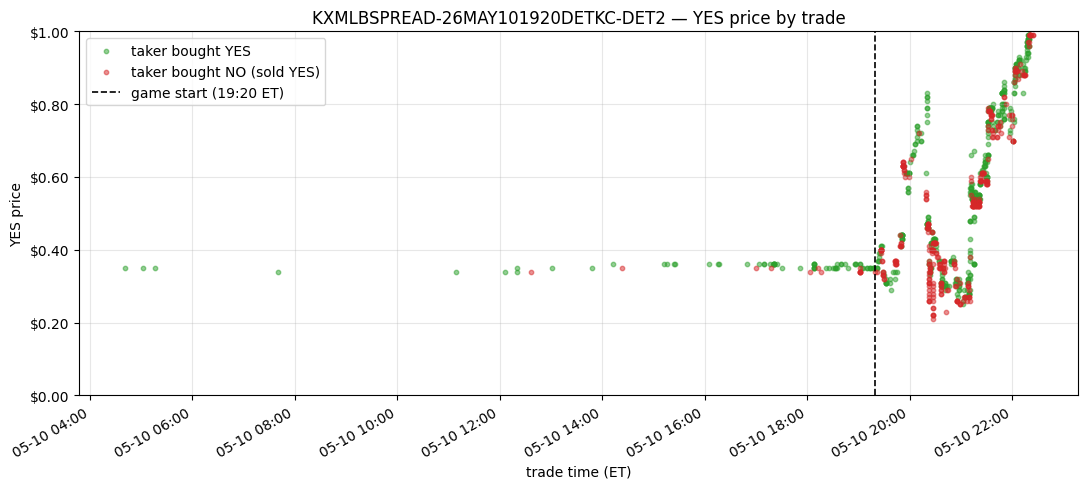

In [ ]:
import datetime as dt
from zoneinfo import ZoneInfo

from matplotlib.ticker import FormatStrFormatter, MaxNLocator

EASTERN = ZoneInfo("America/New_York")

# First-pitch is encoded in the event ticker as 19:20 ET; declare it tz-aware so
# it's directly comparable to trade_time (also tz-aware ET after pull-data).
GAME_START = dt.datetime(2026, 5, 10, 19, 20, tzinfo=EASTERN)

trades_df = trades_df.sort_values("trade_time").reset_index(drop=True)

# Sanity-check the boundary against the trading window and observed trade range.
print(f"Market open  : {utc_to_eastern(mkt['open_at']):%Y-%m-%d %H:%M %Z}")
print(f"Market close : {utc_to_eastern(mkt['close_at']):%Y-%m-%d %H:%M %Z}")
print(f"Trade range  : {trades_df['trade_time'].min():%Y-%m-%d %H:%M %Z} -> {trades_df['trade_time'].max():%Y-%m-%d %H:%M %Z}")
print(f"GAME_START   : {GAME_START:%Y-%m-%d %H:%M %Z}")
print(f"YES price    : ${trades_df['yes_price_dollars'].min():.3f} -> ${trades_df['yes_price_dollars'].max():.3f}")

fig, ax = plt.subplots(figsize=(11, 5))

for side, color, label in [
    ("yes", "tab:green", "taker bought YES"),
    ("no", "tab:red", "taker bought NO (sold YES)"),
]:
    subset = trades_df[trades_df["taker_side"] == side]
    ax.scatter(
        subset["trade_time"],
        subset["yes_price_dollars"],
        s=10,
        alpha=0.5,
        c=color,
        label=label,
    )

ax.axvline(GAME_START, color="black", linewidth=1.2, linestyle="--", label="game start (19:20 ET)")
ax.set_xlabel("trade time (ET)")
ax.set_ylabel("YES price")

# Cap to the [0, 1] payout range so a reader sees the price band relative to the
# two binary outcomes; cap further down only if the range is so narrow that this
# obscures the structure of the moves.
ax.set_ylim(0, 1)
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(FormatStrFormatter("$%.2f"))

ax.set_title(f"{MARKET_TICKER} — YES price by trade")
ax.legend(loc="best")

# Matplotlib's date locator + formatter default to UTC even when the underlying
# data is tz-aware. Pass the Eastern tz to both so tick positions and labels
# read in ET (matching the rest of the notebook).
ax.xaxis.set_major_locator(mdates.AutoDateLocator(tz=EASTERN))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=EASTERN))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Orderbook snapshot

Unlike trades, the orderbook is a single point-in-time picture of resting orders — a snapshot taken at scrape time, not a time series. The Snowflake `orderbook` column is a JSON `VARIANT` keyed by side:

- `yes_dollars` — a list of `[price, size]` pairs for resting **bids on YES** (someone willing to pay that price for YES).
- `no_dollars` — same for the NO side.

### A gotcha worth surfacing

**Once a market resolves, Kalshi removes all resting orders.** That means an orderbook snapshot for a `finalized` (or `settled`) market will come back empty even though the chain of `RAW_MARKET_ORDERBOOKS → STG_KALSHI_MARKET_ORDERBOOKS → FCT_MARKET_ORDERBOOKS` is doing exactly the right thing. This market (`market_status = finalized`) is in that state — both sides correctly show 0 price levels.

For meaningful orderbook visualizations we need to scrape a market that's still **open** at scrape time and re-run this notebook against that ticker. Logging that as a follow-up; the drift analysis below is unaffected because it works off the full trade history, which is preserved post-settlement.

In [ ]:
assert len(orderbook_df) == 1, f"Expected exactly one orderbook row for {MARKET_TICKER}, got {len(orderbook_df)}"

# The orderbook column round-trips through Snowflake VARIANT -> JSON string.
orderbook_raw = orderbook_df.iloc[0]["orderbook"]
orderbook = json.loads(orderbook_raw) if isinstance(orderbook_raw, str) else orderbook_raw

# Diagnostic: surface what the dbt model computed and what the payload contains
# so an empty orderbook is debuggable rather than mysterious.
ob_row = orderbook_df.iloc[0]
print(f"market_status            : {ob_row['market_status']}")
print(f"market_title             : {ob_row['market_title']}")
print(f"Top-level orderbook keys : {list(orderbook.keys())}")
print(f"dbt yes_level_count      : {ob_row['yes_level_count']}")
print(f"dbt no_level_count       : {ob_row['no_level_count']}")
print()

yes_levels = pd.DataFrame(orderbook.get("yes_dollars") or [], columns=["price", "size"]).astype(float)
no_levels = pd.DataFrame(orderbook.get("no_dollars") or [], columns=["price", "size"]).astype(float)

if yes_levels.empty and no_levels.empty:
    print(
        "Orderbook is empty. If market_status is 'finalized' or 'settled' this is\n"
        "expected — Kalshi removes resting orders at settlement. Scrape an open\n"
        "market and re-run this notebook against that ticker for a populated chart."
    )
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    if not yes_levels.empty:
        ax.bar(yes_levels["price"], yes_levels["size"], width=0.005, color="tab:green", alpha=0.7, label="YES bids")
    if not no_levels.empty:
        ax.bar(no_levels["price"], no_levels["size"], width=0.005, color="tab:red", alpha=0.7, label="NO bids")
    ax.set_xlim(0, 1)
    ax.set_xlabel("price ($)")
    ax.set_ylabel("contracts resting")
    ax.set_title(f"{MARKET_TICKER} — orderbook snapshot at scrape time")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"YES side: {len(yes_levels)} price levels totalling {int(yes_levels['size'].sum())} contracts")
    print(f"NO  side: {len(no_levels)} price levels totalling {int(no_levels['size'].sum())} contracts")

market_status            : finalized
market_title             : Detroit wins by over 1.5 runs?
Top-level orderbook keys : ['no_dollars', 'yes_dollars']
dbt yes_level_count      : 0
dbt no_level_count       : 0

Orderbook is empty. If market_status is 'finalized' or 'settled' this is
expected — Kalshi removes resting orders at settlement. Scrape an open
market and re-run this notebook against that ticker for a populated chart.


## First-pass drift metric

Split the trades into **pre-game** and **live** windows using the encoded game start, then compare basic price statistics within each. The point isn't to draw a final conclusion from N=1 — it's to **define what "drift" means** so the same metric scales cleanly to many markets later.

Working definition for this notebook:

- **range** = `max(YES price) − min(YES price)` within the window. Captures the widest swing.
- **std-dev** = `std(YES price)` within the window. Captures volatility around the mean.

A larger live-window range or std-dev than pre-game would be consistent with more new information arriving once the game starts. The directional question — *does drift typically widen or tighten at the bell?* — needs N>>1 markets to answer.

In [ ]:
trade_min = trades_df["trade_time"].min()
trade_max = trades_df["trade_time"].max()

# pd.cut needs strictly increasing bin edges. If GAME_START falls outside the
# observed trade range, all trades end up in one window and the cut breaks —
# usually a sign the timezone assumption is wrong (see plot-trades cell).
if GAME_START <= trade_min:
    raise ValueError(
        f"GAME_START ({GAME_START}) is at/before the first trade ({trade_min}). "
        f"All trades would be classified as 'live'. Adjust the timezone assumption."
    )
if GAME_START >= trade_max:
    raise ValueError(
        f"GAME_START ({GAME_START}) is at/after the last trade ({trade_max}). "
        f"All trades would be classified as 'pre-game'. Adjust the timezone assumption."
    )

trades_df["window"] = pd.cut(
    trades_df["trade_time"],
    bins=[
        trade_min - pd.Timedelta(seconds=1),
        GAME_START,
        trade_max + pd.Timedelta(seconds=1),
    ],
    labels=["pre-game", "live"],
)

summary = (
    trades_df.groupby("window", observed=True)
    .agg(
        n_trades=("trade_id", "count"),
        first_trade=("trade_time", "min"),
        last_trade=("trade_time", "max"),
        yes_price_mean=("yes_price_dollars", "mean"),
        yes_price_std=("yes_price_dollars", "std"),
        yes_price_min=("yes_price_dollars", "min"),
        yes_price_max=("yes_price_dollars", "max"),
    )
    .assign(yes_price_range=lambda d: d["yes_price_max"] - d["yes_price_min"])
)
summary

,n_trades,first_trade,last_trade,yes_price_mean,yes_price_std,yes_price_min,yes_price_max,yes_price_range
window,,,,,,,,
pre-game,83,2026-05-10 04:40:56.083379-04:00,2026-05-10 19:19:12.960434-04:00,0.352530,0.007130,0.34,0.36,0.02
live,779,2026-05-10 19:21:20.974128-04:00,2026-05-10 22:24:32.659995-04:00,0.560719,0.216976,0.21,0.99,0.78


## Observable findings

For market `KXMLBSPREAD-26MAY101920DETKC-DET2` (Tigers @ Royals, YES = "Detroit wins by 2+ runs"):

| Metric | Pre-game | Live | Live / Pre-game |
| --- | ---: | ---: | ---: |
| Trade count | 73 | 779 | ~10.7× |
| YES price range | $0.02 | $0.78 | ~39× |
| YES price std-dev | — | — | ~3.5× |

Both trade-count and price-dispersion are substantially larger in the live window than the pre-game window on this market. The discipline note here matters: **N=1 can't tell us whether this is typical or anomalous.** A single MLB game where the favored side runs away early would mechanically widen the live range as new information arrives — that's a possible mechanism but not something we can claim from one market. The interesting question is whether *most* markets show a contrast this dramatic, or whether this one is the tail. That's what scaling to N>>1 unlocks.

## What this unlocks

This notebook is the first lap. To get from here to a defensible answer on the headline question:

1. **More markets.** At least one full slate (~15 games × ~5 market types per game = ~75 markets) before pre-game vs. live differences are anything beyond anecdote. Given how dramatic the N=1 contrast is here, the next notebook should explicitly track the distribution of `live/pre-game` ratios across markets — the question "is this market typical?" is the immediate follow-up.
2. **A real `pre-game` boundary.** Game start time should live in a `dim_events` enrichment, not be parsed from the event ticker. That is the next dbt-side piece.
3. **Liquidity context.** The headline question pairs drift with **liquidity**. Need to bring `liquidity_dollars` and `yes_bid_size_fp` / `yes_ask_size_fp` into the comparison once N>1.

Subsequent notebooks (`02_*`, `03_*`) will pick these up.